In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set plot style for better visuals
sns.set_theme(style="whitegrid")
%matplotlib inline

# Enforce security context permissions on the JSON key directly from the notebook
NOTEBOOK_DIR = Path(os.getcwd())
PROJECT_ROOT = NOTEBOOK_DIR.parent
DATA_DIR = PROJECT_ROOT / "data"
KAGGLE_TOKEN_PATH = DATA_DIR / "kaggle.json"

if not KAGGLE_TOKEN_PATH.exists():
    raise FileNotFoundError(
        f"🚨 Could not find kaggle.json at: {KAGGLE_TOKEN_PATH.resolve()}\n"
        f"Please paste your security token into the data directory first!"
    )

os.chmod(str(KAGGLE_TOKEN_PATH), 0o600)
os.environ["KAGGLE_CONFIG_DIR"] = str(DATA_DIR)

print("✅ Kaggle CLI configuration successfully initialized.")

✅ Kaggle CLI configuration successfully initialized.


In [6]:
import zipfile
from kaggle.api.kaggle_api_extended import KaggleApi

api = KaggleApi()
api.authenticate()

zip_path = DATA_DIR / "loan-default.zip"
api.dataset_download_files("nikhil1e9/loan-default", path=DATA_DIR, quiet=False)

with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(DATA_DIR)
    csv_candidates = [name for name in z.namelist() if name.lower().endswith(".csv")]

if csv_candidates:
    src = DATA_DIR / csv_candidates[0]
    dst = DATA_DIR / "loan-default.csv"
    if src.exists():
        src.rename(dst)

if zip_path.exists():
    zip_path.unlink()

print("🚀 Download completed. loan-default.csv ready in data folder.")

Dataset URL: https://www.kaggle.com/datasets/nikhil1e9/loan-default


100%|██████████| 7.86M/7.86M [00:02<00:00, 3.82MB/s]



🚀 Download completed. loan-default.csv ready in data folder.


In [7]:
RAW_DATA_PATH = DATA_DIR / "loan-default.csv"

# Check if the file exists before reading to avoid generic errors
if not RAW_DATA_PATH.exists():
    raise FileNotFoundError(
        f"❌ Could not find the dataset at: {RAW_DATA_PATH.resolve()}\n"
        f"Please run your ingestion/download code cell first!"
    )

# Read the data into a Pandas DataFrame
print(f"📖 Loading data from: {RAW_DATA_PATH.name}...")
df = pd.read_csv(RAW_DATA_PATH)

# Inspect the shape and first few rows
print(f"📊 Dataset successfully loaded! Shape: {df.shape[0]:,} rows, {df.shape[1]} columns.\n")
df.head()

📖 Loading data from: loan-default.csv...
📊 Dataset successfully loaded! Shape: 255,347 rows, 18 columns.



,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


In [9]:
# Evaluate class imbalance skew for the risk target
print("⚖️ Target Class Imbalance (Default Vector):")
print(df['Default'].value_counts(normalize=True) * 100)
print(df['Default'].value_counts())

# Audit numerical columns for basic statistics and boundary identification
print("\n🔍 Quantitative Column Summary Statistics:")
numerical_features = ['Age', 'Income', 'CreditScore', 'LoanAmount', 'DTIRatio', 'EmploymentLength']
# Evaluate class imbalance skew for the risk target
print("⚖️ Target Class Imbalance (Default Vector):")
print(df['Default'].value_counts(normalize=True) * 100)
print(df['Default'].value_counts())

# Audit numerical columns for basic statistics and boundary identification
print("\n🔍 Quantitative Column Summary Statistics:")
numerical_features = ['Age', 'Income', 'CreditScore', 'LoanAmount', 'DTIRatio', 'MonthsEmployed']
print(df[numerical_features].describe())

⚖️ Target Class Imbalance (Default Vector):
Default
0    88.387175
1    11.612825
Name: proportion, dtype: float64
Default
0    225694
1     29653
Name: count, dtype: int64

🔍 Quantitative Column Summary Statistics:
⚖️ Target Class Imbalance (Default Vector):
Default
0    88.387175
1    11.612825
Name: proportion, dtype: float64
Default
0    225694
1     29653
Name: count, dtype: int64

🔍 Quantitative Column Summary Statistics:
                 Age         Income    CreditScore     LoanAmount  \
count  255347.000000  255347.000000  255347.000000  255347.000000   
mean       43.498306   82499.304597     574.264346  127578.865512   
std        14.990258   38963.013729     158.903867   70840.706142   
min        18.000000   15000.000000     300.000000    5000.000000   
25%        31.000000   48825.500000     437.000000   66156.000000   
50%        43.000000   82466.000000     574.000000  127556.000000   
75%        56.000000  116219.000000     712.000000  188985.000000   
max        69.00

In [10]:
print("⚖️ Pre-Training Systemic Bias Audit:")

# 1. Segment age into analytical buckets (e.g., Young Applicants vs Mature Applicants)
# Let's use 30 as a threshold proxy to isolate early-career profiles
df['is_young_applicant'] = (df['Age'] < 30).astype(int)

# 2. Calculate historical base default rates per group
base_rates = df.groupby('is_young_applicant')['Default'].mean()
print("\n📊 Historical Default Vector Rates:")
print(f" - Mature Cohort (is_young_applicant = 0): {base_rates[0] * 100:.2f}% default rate")
print(f" - Young Cohort  (is_young_applicant = 1): {base_rates[1] * 100:.2f}% default rate")

# 3. Compute the raw Pre-Training Disparate Impact / Demographic Disparity Ratio
# Formula: (Selection Rate of Unfavorable/Target Outcome for Protected) / (Selection Rate for Baseline)
historical_disparity = base_rates[1] / base_rates[0] if base_rates[0] > 0 else 0
print(f"\n⚠️ Calculated Historical Demographic Disparity Ratio: {historical_disparity:.4f}")

if not (0.80 <= historical_disparity <= 1.25):
    print("🚨 STATUS: Substantial historical bias detected. The raw dataset violates statistical parity guidelines.")
else:
    print("✅ STATUS: Historical distributions are within acceptable regulatory boundaries.")

⚖️ Pre-Training Systemic Bias Audit:

📊 Historical Default Vector Rates:
 - Mature Cohort (is_young_applicant = 0): 9.20% default rate
 - Young Cohort  (is_young_applicant = 1): 19.71% default rate

⚠️ Calculated Historical Demographic Disparity Ratio: 2.1428
🚨 STATUS: Substantial historical bias detected. The raw dataset violates statistical parity guidelines.


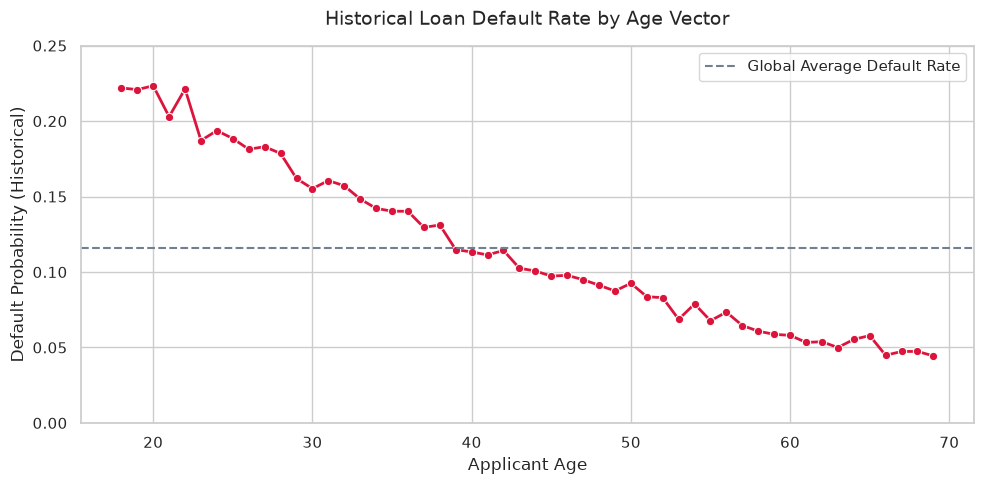

In [12]:
plt.figure(figsize=(10, 5))

# Plot the distribution of default rates by age using a rolling window or discrete bins
age_default_profile = df.groupby('Age')['Default'].mean().reset_index()

sns.lineplot(data=age_default_profile, x='Age', y='Default', marker='o', color='crimson', linewidth=2)
plt.axhline(y=df['Default'].mean(), color='slategrey', linestyle='--', label='Global Average Default Rate')

plt.title('Historical Loan Default Rate by Age Vector', fontsize=14, pad=15)
plt.xlabel('Applicant Age', fontsize=12)
plt.ylabel('Default Probability (Historical)', fontsize=12)
plt.ylim(0, 0.25)
plt.legend()
plt.tight_layout()
plt.show()